# NorthStar Notebook 1: Python Data Processing

This notebook covers the **Python data processing** requirement.

It includes:
- loading the NorthStar CSV dataset
- checking structure, duplicates and missing values
- cleaning zone names and date/time columns
- merging operational datasets
- creating calculated fields
- producing charts and findings
- exporting cleaned files for later use

In [1]:
!pip install pandas numpy matplotlib

import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

pd.set_option("display.max_columns", 100)
print("Libraries loaded")

Libraries loaded


## 1. Upload and extract `northstar_dataset.zip`

In [2]:
zip_name = "northstar_dataset.zip"

if not os.path.exists(zip_name):
    print("Upload northstar_dataset.zip")
    uploaded = files.upload()

extract_folder = "northstar_dataset_extracted"

with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall(extract_folder)

for root, dirs, filenames in os.walk(extract_folder):
    for filename in filenames:
        print(os.path.join(root, filename))

Upload northstar_dataset.zip


Saving northstar_dataset.zip to northstar_dataset.zip
northstar_dataset_extracted/northstar_dataset/deliveries.csv
northstar_dataset_extracted/northstar_dataset/orders.csv
northstar_dataset_extracted/northstar_dataset/hubs.csv
northstar_dataset_extracted/northstar_dataset/customers.csv
northstar_dataset_extracted/northstar_dataset/app_events.csv
northstar_dataset_extracted/northstar_dataset/data_dictionary.csv
northstar_dataset_extracted/northstar_dataset/complaints.csv
northstar_dataset_extracted/northstar_dataset/incidents.csv
northstar_dataset_extracted/northstar_dataset/vehicles.csv
northstar_dataset_extracted/northstar_dataset/README.txt
northstar_dataset_extracted/northstar_dataset/drivers.csv


## 2. Load CSV files

In [3]:
base_path = None
for root, dirs, filenames in os.walk(extract_folder):
    if "orders.csv" in filenames:
        base_path = root
        break

orders = pd.read_csv(os.path.join(base_path, "orders.csv"))
deliveries = pd.read_csv(os.path.join(base_path, "deliveries.csv"))
customers = pd.read_csv(os.path.join(base_path, "customers.csv"))
complaints = pd.read_csv(os.path.join(base_path, "complaints.csv"))
app_events = pd.read_csv(os.path.join(base_path, "app_events.csv"))
drivers = pd.read_csv(os.path.join(base_path, "drivers.csv"))
vehicles = pd.read_csv(os.path.join(base_path, "vehicles.csv"))
incidents = pd.read_csv(os.path.join(base_path, "incidents.csv"))
hubs = pd.read_csv(os.path.join(base_path, "hubs.csv"))

datasets = {
    "orders": orders, "deliveries": deliveries, "customers": customers,
    "complaints": complaints, "app_events": app_events, "drivers": drivers,
    "vehicles": vehicles, "incidents": incidents, "hubs": hubs
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")

orders: 1250 rows, 11 columns
deliveries: 950 rows, 13 columns
customers: 650 rows, 9 columns
complaints: 320 rows, 10 columns
app_events: 640 rows, 10 columns
drivers: 170 rows, 8 columns
vehicles: 120 rows, 8 columns
incidents: 280 rows, 7 columns
hubs: 8 rows, 5 columns


## 3. Data quality checks

In [4]:
quality_summary = []
for name, df in datasets.items():
    quality_summary.append({
        "dataset": name,
        "rows": len(df),
        "columns": len(df.columns),
        "duplicate_rows": df.duplicated().sum(),
        "total_missing_values": int(df.isna().sum().sum())
    })

quality_summary_df = pd.DataFrame(quality_summary)
quality_summary_df

,dataset,rows,columns,duplicate_rows,total_missing_values
0,orders,1250,11,0,25
1,deliveries,950,13,0,33
2,customers,650,9,0,33
3,complaints,320,10,0,16
4,app_events,640,10,0,144
5,drivers,170,8,0,7
6,vehicles,120,8,0,4
7,incidents,280,7,0,17
8,hubs,8,5,0,0


In [5]:
for name, df in datasets.items():
    print("\n", name.upper())
    print(df.isna().sum().sort_values(ascending=False).head(10))


 ORDERS
booking_channel          25
customer_id               0
order_id                  0
service_type              0
order_created_at          0
pickup_zone               0
promised_window_hours     0
dropoff_zone              0
priority_level            0
order_value               0
dtype: int64

 DELIVERIES
delivery_completed_at            19
customer_rating_post_delivery    14
driver_id                         0
order_id                          0
delivery_id                       0
hub_id                            0
vehicle_id                        0
delivery_status                   0
dispatch_time                     0
route_distance_km                 0
dtype: int64

 CUSTOMERS
loyalty_score           20
preferred_channel       13
customer_id              0
age                      0
home_zone                0
signup_date              0
customer_type            0
app_engagement_score     0
account_status           0
dtype: int64

 COMPLAINTS
compensation_amount    16
compl

## 4. Clean zone names and date columns

In [6]:
def clean_zone(x):
    if pd.isna(x):
        return x
    return str(x).strip().title()

zone_columns = {
    "orders": ["pickup_zone", "dropoff_zone"],
    "customers": ["home_zone"],
    "app_events": ["zone_context"],
    "drivers": ["base_zone"],
    "vehicles": ["assigned_zone"],
    "hubs": ["zone"]
}

for name, cols in zone_columns.items():
    for col in cols:
        if col in datasets[name].columns:
            datasets[name][col] = datasets[name][col].apply(clean_zone)

date_columns = {
    "orders": ["order_created_at"],
    "deliveries": ["dispatch_time", "delivery_completed_at"],
    "customers": ["signup_date"],
    "complaints": ["created_at"],
    "app_events": ["event_timestamp"],
    "vehicles": ["commission_date"],
    "incidents": ["reported_at"]
}

for name, cols in date_columns.items():
    for col in cols:
        if col in datasets[name].columns:
            datasets[name][col] = pd.to_datetime(datasets[name][col], errors="coerce")

print("Cleaning completed")

Cleaning completed


## 5. Create calculated fields

In [7]:
deliveries["delivery_duration_hours"] = (
    deliveries["delivery_completed_at"] - deliveries["dispatch_time"]
).dt.total_seconds() / 3600

deliveries["is_failed"] = np.where(deliveries["delivery_status"].str.lower() == "failed", 1, 0)
deliveries[["delivery_id", "delivery_status", "delivery_duration_hours", "is_failed"]].head()

,delivery_id,delivery_status,delivery_duration_hours,is_failed
0,DL00001,Failed,22.149973,1
1,DL00002,OnTime,-1.100000,0
2,DL00003,OnTime,1.108991,0
3,DL00004,Delayed,23.985584,0
4,DL00005,OnTime,4.042814,0


## 6. Merge operational datasets

In [8]:
ops = deliveries.merge(orders, on="order_id", how="left") \
    .merge(customers, on="customer_id", how="left") \
    .merge(drivers, on="driver_id", how="left") \
    .merge(vehicles, on="vehicle_id", how="left") \
    .merge(hubs, on="hub_id", how="left", suffixes=("", "_hub"))

print("Integrated operational dataset:", ops.shape)
ops.head()

Integrated operational dataset: (950, 51)


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,delivery_duration_hours,is_failed,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status,base_zone,employment_type,years_experience,training_score,driver_rating,shift_preference,active_flag,vehicle_type,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version,hub_name,zone,hub_type,capacity_score
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05,22.149973,1,C0567,Business,2024-06-18 09:48:00,6,Central,Central,Medium,151.14,Web,0,74,East,Consumer,2024-02-18 04:31:00,79.7,64.9,App,Active,Airport,PartTime,13,88.9,4.75,Morning,1,EV,Central,2024-06-09 16:18:00,78.4,29849,Active,v2.2,Central Core,Central,Control,88
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41,-1.100000,0,C0520,Parcel,2025-01-11 17:15:00,2,Riverside,North,Medium,10.04,App,1,50,North,Consumer,2025-04-21 07:28:00,53.6,80.4,Partner API,Active,Ctr,PartTime,11,69.2,4.61,Evening,1,Diesel,Airport,2025-09-17 08:52:00,68.6,78468,Active,v2.2,South Link,South,Dispatch,78
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51,1.108991,0,C0480,Medical,2025-06-02 19:12:00,2,Central,North,Medium,141.93,Web,0,26,North,Enterprise,2025-03-02 00:55:00,67.6,49.6,App,Dormant,Central,FullTime,8,78.8,4.38,Flexible,1,Diesel,East,2025-12-09 16:47:00,55.9,15278,Active,v2.2,South Link,South,Dispatch,78
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62,23.985584,0,C0616,Medical,2024-03-08 20:58:00,24,South,North,Low,11.11,App,0,49,Riverside,Consumer,2024-11-30 06:56:00,65.9,78.2,Phone,Active,Central,FullTime,4,58.2,4.19,Morning,1,Hybrid,East,2025-06-05 13:40:00,83.3,85635,Active,v2.1,South Link,South,Dispatch,78
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22,4.042814,0,C0276,Medical,2025-09-21 09:29:00,6,Riverside,Riverside,High,76.02,App,0,47,South,Consumer,2024-11-15 02:59:00,66.9,76.6,App,Active,South,FullTime,10,70.6,4.33,Morning,1,EV,Riverside,2025-05-24 09:58:00,94.2,210683,InRepair,v2.0,North Exchange,North,Dispatch,82


## 7. Delivery status analysis

In [9]:
delivery_status_summary = deliveries["delivery_status"].value_counts().reset_index()
delivery_status_summary.columns = ["delivery_status", "count"]
delivery_status_summary

,delivery_status,count
0,OnTime,616
1,Delayed,202
2,Failed,132


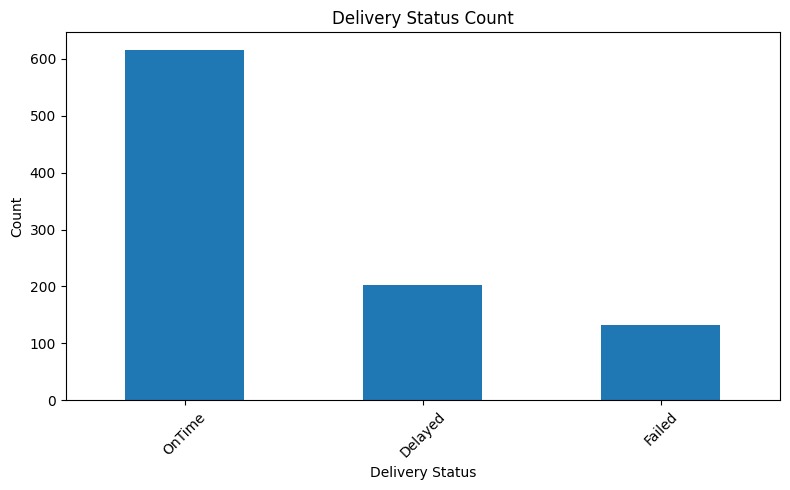

In [10]:
plt.figure(figsize=(8,5))
deliveries["delivery_status"].value_counts().plot(kind="bar")
plt.title("Delivery Status Count")
plt.xlabel("Delivery Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Failure rate by dropoff zone

In [11]:
zone_performance = ops.groupby("dropoff_zone").agg(
    total_deliveries=("delivery_id", "count"),
    failed_deliveries=("is_failed", "sum"),
    average_rating=("customer_rating_post_delivery", "mean"),
    average_route_overrides=("manual_route_override_count", "mean"),
    average_cost=("fuel_or_charge_cost", "mean")
).reset_index()

zone_performance["failure_rate_pct"] = (
    zone_performance["failed_deliveries"] / zone_performance["total_deliveries"] * 100
).round(2)

zone_performance.sort_values("failure_rate_pct", ascending=False)

,dropoff_zone,total_deliveries,failed_deliveries,average_rating,average_route_overrides,average_cost,failure_rate_pct
1,Central,98,18,3.782292,1.081633,12.660408,18.37
4,North,145,25,3.830979,0.979310,13.337586,17.24
2,Ctr,49,7,3.734694,0.836735,12.659184,14.29
6,South,130,18,3.847187,0.923077,12.358846,13.85
5,Riverside,141,19,3.957357,0.950355,13.207092,13.48
3,East,118,14,3.857778,0.974576,12.916441,11.86
7,West,146,17,3.923077,0.952055,13.156438,11.64
0,Airport,123,14,3.871500,1.008130,12.117317,11.38


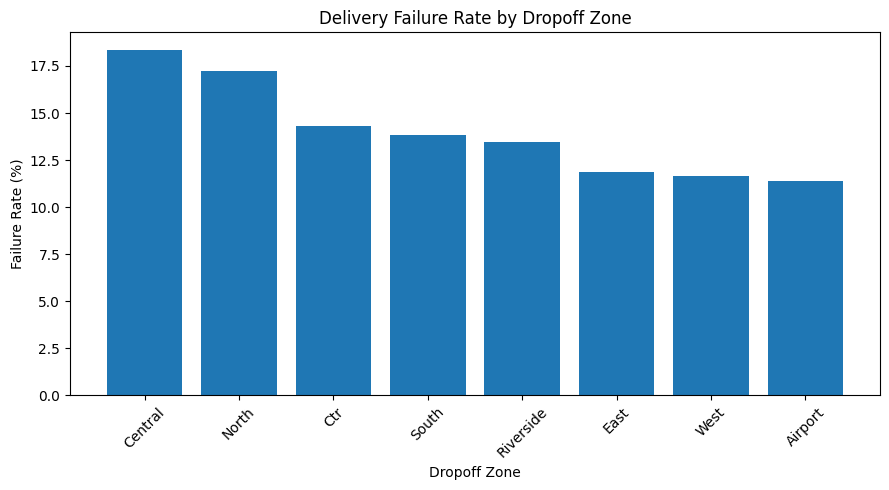

In [12]:
zone_plot = zone_performance.sort_values("failure_rate_pct", ascending=False)

plt.figure(figsize=(9,5))
plt.bar(zone_plot["dropoff_zone"], zone_plot["failure_rate_pct"])
plt.title("Delivery Failure Rate by Dropoff Zone")
plt.xlabel("Dropoff Zone")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. Complaints analysis

In [13]:
complaint_summary = complaints.groupby("complaint_type").agg(
    complaint_count=("complaint_id", "count"),
    average_resolution_days=("resolution_days", "mean"),
    average_compensation=("compensation_amount", "mean")
).reset_index().sort_values("complaint_count", ascending=False)

complaint_summary

,complaint_type,complaint_count,average_resolution_days,average_compensation
3,Delay,101,7.257426,18.051489
5,MissedPickup,64,7.640625,22.593651
0,AppIssue,53,8.603774,19.614400
4,DriverBehaviour,51,8.156863,21.153478
6,SupportExperience,20,7.450000,17.125000
1,Billing,16,7.750000,23.871250
2,Damage,15,11.333333,23.982000


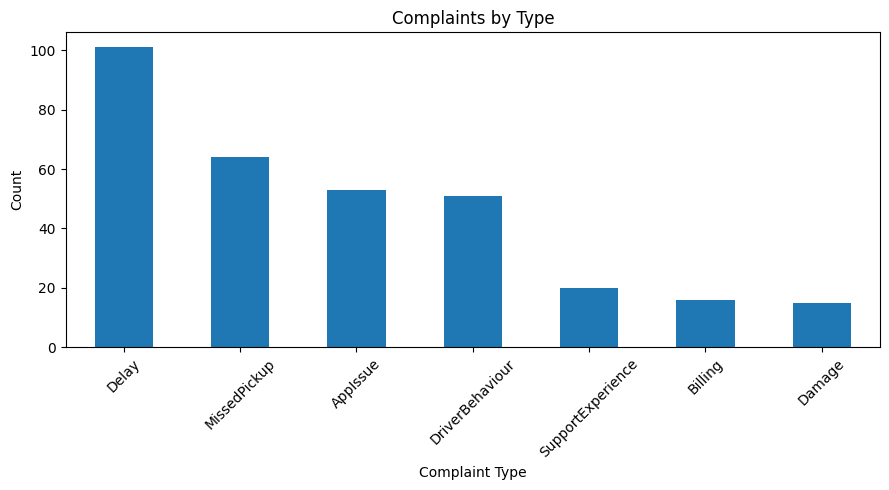

In [14]:
plt.figure(figsize=(9,5))
complaints["complaint_type"].value_counts().plot(kind="bar")
plt.title("Complaints by Type")
plt.xlabel("Complaint Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10. Route override analysis

In [15]:
correlation = ops[[
    "manual_route_override_count",
    "customer_rating_post_delivery",
    "fuel_or_charge_cost",
    "delivery_duration_hours"
]].corr()

correlation

,manual_route_override_count,customer_rating_post_delivery,fuel_or_charge_cost,delivery_duration_hours
manual_route_override_count,1.000000,-0.059903,0.098690,-0.013711
customer_rating_post_delivery,-0.059903,1.000000,-0.059062,-0.305731
fuel_or_charge_cost,0.098690,-0.059062,1.000000,0.049378
delivery_duration_hours,-0.013711,-0.305731,0.049378,1.000000


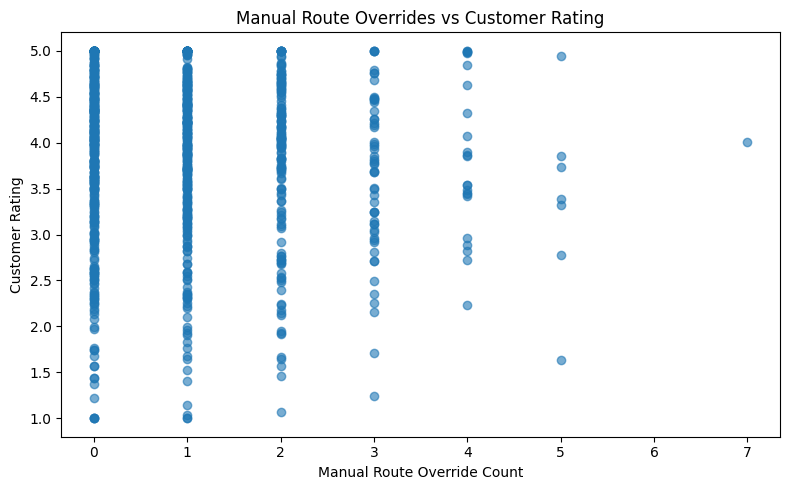

In [16]:
plt.figure(figsize=(8,5))
plt.scatter(ops["manual_route_override_count"], ops["customer_rating_post_delivery"], alpha=0.6)
plt.title("Manual Route Overrides vs Customer Rating")
plt.xlabel("Manual Route Override Count")
plt.ylabel("Customer Rating")
plt.tight_layout()
plt.show()

## 11. Hub performance

In [17]:
hub_performance = ops.groupby(["hub_id", "hub_name", "zone"]).agg(
    total_deliveries=("delivery_id", "count"),
    failed_deliveries=("is_failed", "sum"),
    average_rating=("customer_rating_post_delivery", "mean"),
    average_cost=("fuel_or_charge_cost", "mean")
).reset_index()

hub_performance["failure_rate_pct"] = (
    hub_performance["failed_deliveries"] / hub_performance["total_deliveries"] * 100
).round(2)

hub_performance.sort_values("failure_rate_pct", ascending=False)

,hub_id,hub_name,zone,total_deliveries,failed_deliveries,average_rating,average_cost,failure_rate_pct
7,H08,Midtown Relay,Central,128,26,3.884560,11.708203,20.31
4,H05,Central Core,Central,115,23,3.669558,13.686000,20.00
5,H06,Airport Hub,Airport,104,15,3.882136,13.319231,14.42
3,H04,West Gate,West,127,16,3.915476,13.167008,12.60
0,H01,North Exchange,North,136,17,3.840593,12.755809,12.50
6,H07,Riverside Hub,Riverside,115,14,3.881858,12.922087,12.17
1,H02,South Link,South,106,10,3.950952,12.565000,9.43
2,H03,East Dock,East,119,11,3.895862,12.744202,9.24


## 12. Export cleaned outputs

In [18]:
output_folder = "northstar_python_outputs"
os.makedirs(output_folder, exist_ok=True)

quality_summary_df.to_csv(os.path.join(output_folder, "quality_summary.csv"), index=False)
zone_performance.to_csv(os.path.join(output_folder, "zone_performance.csv"), index=False)
complaint_summary.to_csv(os.path.join(output_folder, "complaint_summary.csv"), index=False)
hub_performance.to_csv(os.path.join(output_folder, "hub_performance.csv"), index=False)
ops.to_csv(os.path.join(output_folder, "integrated_operations_dataset.csv"), index=False)

print("Exported files:", os.listdir(output_folder))

Exported files: ['quality_summary.csv', 'hub_performance.csv', 'zone_performance.csv', 'complaint_summary.csv', 'integrated_operations_dataset.csv']
